# <img src="https://img.icons8.com/bubbles/50/000000/mind-map.png" style="height:50px;display:inline"> ECE 046211 - Technion - Deep Learning
---

## HW3 - Sequential Tasks and Training Methods
---

### <img src="https://img.icons8.com/clouds/96/000000/keyboard.png" style="height:50px;display:inline"> Keyboard Shortcuts
---
* Run current cell: **Ctrl + Enter**
* Run current cell and move to the next: **Shift + Enter**
* Show lines in a code cell: **Esc + L**
* View function documentation: **Shift + Tab** inside the parenthesis or `help(name_of_module)`
* New cell below: **Esc + B**
* Delete cell: **Esc + D, D** (two D's)

### <img src="https://img.icons8.com/bubbles/50/000000/information.png" style="height:50px;display:inline"> Students Information
---
* Fill in

|Name     |Campus Email| ID  |
|---------|--------------------------------|----------|
|Student 1| student_1@campus.technion.ac.il| 123456789|
|Student 2| student_2@campus.technion.ac.il| 987654321|


### <img src="https://img.icons8.com/bubbles/50/000000/upload-to-cloud.png" style="height:50px;display:inline"> Submission Guidelines
---
* Maximal garde: 100.
* Submission only in **pairs**. 
    * Please make sure you have registered your group in Moodle (there is a group creation component on the Moodle where you need to create your group and assign members).
* **No handwritten submissions.** You can choose whether to answer in a Markdown cell in this notebook or attach a PDF with your answers.
* <a style='color:red'> SAVE THE NOTEBOOKS WITH THE OUTPUT, CODE CELLS THAT WERE NOT RUN WILL NOT GET ANY POINTS! </a>
* What you have to submit:
    * If you have answered the questions in the notebook, you should submit this file only, with the name: `ece046211_hw3_id1_id2.ipynb`.
    * If you answered the questionss in a different file you should submit a `.zip` file with the name `ece046211_hw3_id1_id2.zip` with content:
        * `ece046211_hw3_id1_id2.ipynb` - the code tasks
        * `ece046211_hw3_id1_id2.pdf` - answers to questions.
    * No other file-types (`.py`, `.docx`...) will be accepted.
* Submission on the course website (Moodle).
* **Latex in Colab** - in some cases, Latex equations may no be rendered. To avoid this, make sure to not use *bullets* in your answers ("* some text here with Latex equations" -> "some text here with Latex equations").

### <img src="https://img.icons8.com/dusk/64/000000/online.png" style="height:50px;display:inline"> Working Online and Locally
---
* You can choose your working environment:
    1. `Jupyter Notebook`, **locally** with <a href="https://www.anaconda.com/distribution/">Anaconda</a> or **online** on <a href="https://colab.research.google.com/">Google Colab</a>
        * Colab also supports running code on GPU, so if you don't have one, Colab is the way to go. To enable GPU on Colab, in the menu: `Runtime`$\rightarrow$ `Change Runtime Type` $\rightarrow$`GPU`.
    2. Python IDE such as <a href="https://www.jetbrains.com/pycharm/">PyCharm</a> or <a href="https://code.visualstudio.com/">Visual Studio Code</a>.
        * Both allow editing and running Jupyter Notebooks.

* Please refer to `Setting Up the Working Environment.pdf` on the Moodle or our GitHub (https://github.com/taldatech/ee046211-deep-learning) to help you get everything installed.
* If you need any technical assistance, please go to our Piazza forum (`hw3` folder) and describe your problem (preferably with images).

### <img src="https://img.icons8.com/bubbles/50/000000/checklist.png" style="height:50px;display:inline"> Agenda
---
* [Part 1 - Theory](#-Part-1---Theory)
    * [Q1 - Masking in Transformers](#-Question-1---Masking-in-Transformers) 
    * [Q2 - Preventing Variance Explosion](#-Question-2---Preventing-Variance-Explosion)
    * [Q3 - Recurrent Neural Networks](#-Question-3---Recurrent-Neural-Networks)
* [Part 2 - Code Assignments - Sequence-to-Sequence with Transformers](#-Part-2---Code-Assignments)
    * [Task 1 - Loading and Observing the Data](#-Task-1----Loading-and-Observing-the-Data)
    * [Task 2 - Preparing the Data - Separating to Inputs and Targets](#-Task-2----Preparing-the--Data---Separating-to-Inputs-and-Targets)
    * [Task 3 - Define Hyperparameters and Initialize the Model](#-Task-3----Define-Hyperparameters-and-Initialize-the-Model)
    * [Task 4 - Train and Evaluate the Language Model](#-Task-4----Train-and-Evaluate-the-Language-Model)
    * [Task 5 - Generate Sentences](#-Task-5----Generate-Sentences)
* [Credits](#-Credits)

### <img src="https://img.icons8.com/cute-clipart/64/000000/ball-point-pen.png" style="height:50px;display:inline"> Part 1 - Theory
---
* You can choose whether to answser these straight in the notebook (Markdown + Latex) or use another editor (Word, LyX, Latex, Overleaf...) and submit an additional PDF file, **but no handwritten submissions**.
* You can attach additional figures (drawings, graphs,...) in a separate PDF file, just make sure to refer to them in your answers.

* $\large\LaTeX$ <a href="https://kapeli.com/cheat_sheets/LaTeX_Math_Symbols.docset/Contents/Resources/Documents/index">Cheat-Sheet</a> (to write equations)
    * <a href="http://tug.ctan.org/info/latex-refsheet/LaTeX_RefSheet.pdf">Another Cheat-Sheet</a>


## <img src="https://img.icons8.com/clouds/100/000000/question-mark.png" style="height:50px;display:inline"> Question 1 - Attention
---
A Multi-Head Self-Attention (MHSA) layer is applied to an input
$$\mathbf{X}\in\mathbb{R}^{T\times Hd},$$
with weight matrices
$$\mathbf{W}_Q^h,\mathbf{W}_K^h,\mathbf{W}_V^h\in\mathbb{R}^{Hd\times d},\qquad \mathbf{W}_O^h\in\mathbb{R}^{d\times Hd}.$$
Recall that this layer performs the following operations:

1.

$$\forall h\le H:\qquad
\mathbf{X}\mathbf{W}_Q^h=\mathbf{Q}^h,\quad
\mathbf{X}\mathbf{W}_K^h=\mathbf{K}^h,\quad
\mathbf{X}\mathbf{W}_V^h=\mathbf{V}^h$$

2.

$$\forall h\le H:\qquad
\mathbf{U}^h=\mathbf{Q}^h(\mathbf{K}^h)^\top/\sqrt d,$$

and
$$MHSA(\mathbf{X})=\sum_{h=1}^{H}\left(\mathrm{Softmax}(\mathbf{U}^h),\mathbf{V}^h,\mathbf{W}_O^h\right).$$

**(1)** In which common network architecture does this layer appear?
State two advantages and one disadvantage of this architecture compared to recurrent neural networks.



One difficulty in computing MHSA is the memory required to store
$$\mathbf{U}^h$$
before applying the Softmax.

**(2.1)** Write explicitly the dimensions of
$$\mathbf{U}^h,\quad \mathbf{Q}^h,\quad \mathbf{K}^h,\quad \mathbf{V}^h.$$

**(2.2)** How can we write
$$\mathrm{Softmax}(\mathbf{U}^h)[i,j]$$
as a function of $$\mathbf{U}^h$$ in a way that avoids exponential overflow? Explain why.
From here on, assume every Softmax is computed in this manner.

**(2.3)** Along which dimension is it easiest to parallelize this function (i.e., the dimension in which the computations are independent)?



**(3)** To address the memory issue, it is proposed to divide each row of $$\mathbf{U}^h$$ into two blocks:

$$J_1=[1,\ldots,T/2],\qquad J_2=[T/2+1,\ldots,T],$$

and for each block $(r\in{1,2})$ compute
$(\mathrm{Softmax}, U_{i,J_r}[:])$,
its normalization coefficient $(n_r[i])$,
and
$$m_r[i]=\max_{k\in J_r}\mathbf{U}^h[i,k].$$

How can we compute
$$\mathrm{Softmax}\left(U[i,:]\right)$$
(over both blocks together) using the results computed in each block?
Assume (T) is even.



The following questions are independent of the previous ones.

Another issue in computing steps (1) and (2) is the number of multiplications required.

**(4)** How many multiplications are required in total, excluding the Softmax operation?
Assume naïve matrix multiplication: for
$$A\in\mathbb{R}^{d_1\times d_2},\ B\in\mathbb{R}^{d_2\times d_3},$$
the multiplication cost of (AB) is (d_1 d_2 d_3).
Also assume the order of operations is (1) then (2), and within each equation left to right.



**(5)** To reduce computation, it is proposed to omit part of the elements used in the calculation.
Formally, define a collection of index sets ({S_i}_{i=1}^T), where each
$$S_i\subset{1,\ldots,T}$$
contains (M) distinct indices, and define
$$\mathbf{A}[S_i,:][j,k]=A[S_i[j],k].$$

Now the computation in equation (2) becomes:

$$\forall h\le H,\forall i\le T:\qquad
\mathbf{U}^h[i,S_i]
=\mathbf{Q}^h[i,:]\left(\mathbf{K}^h[S_i,:]\right)^\top/\sqrt d;$$

$$\forall i\le T:\qquad
MHSA(\mathbf{X})[i,:]
=\sum_{h=1}^H\left(\mathrm{Softmax}\left(\mathbf{U}^h[i,S_i]\right), \mathbf{V}^h[S_i,:], \mathbf{W}_O^h\right).$$

**How many multiplications are required in total (using the same rules as above)?**
For which values of (M,T,d) is this reduction significant?




## <img src="https://img.icons8.com/clouds/100/000000/question-mark.png" style="height:50px;display:inline"> Question 2 - Preventing Variance Explosion
---
This question relates to lectures 8-9 (from slide 7):

Find an initializtion scheme such that $$ \forall l, i,: \text{(1) } \mathbb{E}\left[F_l(u_l)|u_l\right]=0, \text{ (2) } Var(u_l[i]) = 1, $$ assuming skip connections: $u_{l+1} = u_l + F_l(u_l)$ with a single skip $F_l(u_l)=W_l\phi(u_l)+b_l$ and the activation is ReLU: $\phi(x) = \text{ReLU}(x) = \max(0,x)$. 

## <img src="https://img.icons8.com/clouds/100/000000/question-mark.png" style="height:50px;display:inline"> Question 3 - Recurrent Neural Networks
---
You are given a recurrent/feedback neural network with LReLU activations $\phi(u) = \max[pu,u]$, with input $x_t$ and a representation $v_t \in \mathbb{R}^d$ that is updated as follows:
$$ \forall \tau=1,2,...t\:: v_{\tau}=\phi(u_{\tau})\:, u_{\tau} = Wv_{\tau - 1} + B x_{\tau},$$
from initialization $v_0$, and outputs $\hat{y}_t=Cv_t$. The network is trained with GD on a single long series $\{x_{\tau}, y_{\tau}\}_{\tau=1}^t$ with a cost function $\ell(y_t, \hat{y}_t)$ over the last term in the series.

1. Calculate the exact gradient $\frac{\partial \ell}{\partial W[i,j]}$ using Backpropagation through time (BPTT).
2. Recall that calculating the gradient using the method in the previous section there are two issues for $t \to \infty$: (1) the required computational resources grow indefinitely, and (2) the gradients explode or vanish. For each problem: explain it, provide an example for a method to alleviate it and describe any limitations of this method.

### <img src="https://img.icons8.com/officel/80/000000/code.png" style="height:50px;display:inline"> Part 2 - Code Assignments
---
* You must write your code in this notebook and save it with the output of all of the code cells.
* Additional text can be added in Markdown cells.
* You can use any other IDE you like (PyCharm, VSCode...) to write/debug your code, but for the submission you must copy it to this notebook, run the code and save the notebook with the output.

In [ ]:
# this part uses the Wikitext-2 dataset. To access torchtext datasets, please install `torchdata`:
# `pip install torchdata` ir `conda install -c pytorch torchdata` in activated environment 
# or `!pip install torchdata` on colab.
!pip install torchdata
# notes:
# torch=2.0.0 <-> torchtext 0.15.1
# torch=1.13.0 <-> torchtext 0.14.0
# torch=1.12.1 <-> torchtext 0.13.1
# downgrading torchtext example: !pip install torchtext==0.13.1 --no-deps
# torchtext requires the `portalocker` package to download datasets:
!pip install portalocker

In [1]:
# imports for the practice (you can add more if you need)
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import math
from typing import Tuple

# pytorch
import torch
from torch import nn, Tensor
import torch.nn.functional as F
from torch.nn import TransformerEncoder, TransformerEncoderLayer
from torch.utils.data import dataset

# torchtext
import torchtext
from torchtext.datasets import WikiText2
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

seed = 211
np.random.seed(seed)
torch.manual_seed(seed)

In [2]:
# imports for the practice (you can add more if you need)
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import math
from typing import Tuple

# pytorch
import torch
from torch import nn, Tensor
import torch.nn.functional as F
from torch.nn import TransformerEncoder, TransformerEncoderLayer
from torch.utils.data import dataset

# torchtext
import torchtext
from torchtext.datasets import WikiText2
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

seed = 211
np.random.seed(seed)
torch.manual_seed(seed)

Using device: cuda


In [3]:
print(f'pytorch: {torch.__version__}, torchtext: {torchtext.__version__}')

pytorch: 2.0.0+cu117, torchtext: 0.15.0


## <img src="https://img.icons8.com/bubbles/50/000000/workflow.png" style="height:50px;display:inline">  Sequence-to-Sequence with Transformers
---
* In this exercise, you are going to build a language model using PyTroch's Transformer module.
* We will work with the **Wikitext-2** dataset: the WikiText language modeling dataset is a collection of over 100 million tokens extracted from the set of verified Good and Featured articles on Wikipedia.
* After training, you will be able to generate senetences!

### <img src="https://img.icons8.com/color/48/000000/code.png" style="height:50px;display:inline"> Task 1  - Loading and Observing the Data
---
1. Run the following cells that define the functions `batchify` and `data_process` and initialize the tokenizer, vocabulary and the WikiText2 train dataset.
2. Create the train, valid and test data using the provided `batchify` function.
5. Print the shape of `train_data`, write in a comment the meaning of each dimension (e.g. `# [meaning of dim1, meaning of dim2]`).
6. Print the first 20 words of one training sample from `train_data`. Use the vocabulary you built to transfer between tokens to words: `itos = vocab.vocab.get_itos()` will give a "int to string" list.

In [4]:
def batchify(data, bsz):
    """Divides the data into bsz separate sequences, removing extra elements
    that wouldn't cleanly fit.

    Args:
        data: Tensor, shape [N]
        bsz: int, batch size

    Returns:
        Tensor of shape [N // bsz, bsz]
    """
    seq_len = data.size(0) // bsz
    data = data[:seq_len * bsz]
    data = data.view(bsz, seq_len).t().contiguous()
    return data.to(device)

In [5]:
def data_process(raw_text_iter: dataset.IterableDataset) -> Tensor:
    """Converts raw text into a flat Tensor."""
    data = [torch.tensor(vocab(tokenizer(item)), dtype=torch.long) for item in raw_text_iter]
    return torch.cat(tuple(filter(lambda t: t.numel() > 0, data)))

In [6]:
train_iter = WikiText2(root="./data", split='train')
tokenizer = get_tokenizer('basic_english')
vocab = build_vocab_from_iterator(map(tokenizer, train_iter), specials=['<unk>'])
vocab.set_default_index(vocab['<unk>'])

In [7]:
# train_iter was "consumed" by the process of building the vocab,
# so we have to create it again
train_iter, val_iter, test_iter = WikiText2(root="./data")
train_data = data_process(train_iter)
val_data = data_process(val_iter)
test_data = data_process(test_iter)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [29]:
batch_size = 20
eval_batch_size = 10

In [9]:
train_data = batchify(train_data, batch_size)
val_data = batchify(val_data, eval_batch_size)
test_data = batchify(test_data, eval_batch_size)

In [ ]:
print(f"train_data shape: {train_data.size()}") # shape = [sequence_length, batch_size]

train_data shape: torch.Size([102499, 20])


In [36]:
head = train_data[:20, 0]
itos = vocab.vocab.get_itos()
print(" ".join([itos[i] for i in head]))

= valkyria chronicles iii = senjō no valkyria 3 <unk> chronicles ( japanese 戦場のヴァルキュリア3 , lit . valkyria of the


### <img src="https://img.icons8.com/color/48/000000/code.png" style="height:50px;display:inline"> Task 2  - Preparing the  Data - Separating to Inputs and Targets
---
* For a language modeling task, the model needs the following words as `Target`.
    * For example, for the senetence "I have a nice dog", the model will be given "I have a nice" as input, and "have a nice dog" as the target.
* Implement (complete) the function `get_batch(source, i, bptt)`: it generates the input and target sequence for the transformer model. It subdivides the source data into chunks of length `bptt`.
    * For example, for `bptt=2` and at `i=0`, the output of `data, target = get_batch(train_data, i=0, bptt=2)`: `data` will be of shape (2, 20), where the batch size is 20 and `target` will be of length 40 (the target for each element is two words, but we flatten `target`).
    * Example: for `bptt=2`, and the ABCDEFG... characters as input, our batches will be in the form of: `data=[a, b], target=[b, c]`. For `bptt=3`: `data=[a, b, c], target=[b, c, d]` and so on. This one example is a batch.
    * Print a sample from `data` and `target`.

In [59]:
"""
Your Code Here
"""
def get_batch(source, i, bptt):
    """
    Args:
        source: Tensor, shape [full_seq_len, batch_size]
        i: int
        bptt: int
    Returns:
        tuple (data, target), where data has shape [seq_len, batch_size] and
        target has shape [seq_len * batch_size]
    """
    seq_len = min(bptt, len(source) - 1 - i)
    data = source[i:i + seq_len]
    target = source[i + 1:i + 1 + seq_len]
    return data, target.flatten()

In [ ]:
example_data, example_target = get_batch(train_data, 0, bptt=3)

print(f"Data shape: {example_data.shape}, Target shape: {example_target.shape}")
print("\nFirst sequence from data (input):")
print(" ".join([itos[i] for i in example_data[:, 0]]))  # Shows [a, b, c]
print("\nCorresponding targets (next words):")
# For sequence 0, targets are at indices: 0, 20, 40
print(" ".join([itos[example_target[t * batch_size + 0]] for t in range(3)]))  # Shows [b, c, d]

Data shape: torch.Size([3, 20]), Target shape: torch.Size([60])

First sequence from data (input):
= valkyria chronicles

Corresponding targets (next words):
valkyria chronicles iii


### <img src="https://img.icons8.com/color/48/000000/code.png" style="height:50px;display:inline"> Task 3  - Define Hyperparameters and Initialize the Model
---
* Define the following hyperparameters (`[a, b]` means in the range between `a` and `b`):
    * Embedding size: choose from `[200, 250]`
    * Number of hidden units: choose from `[200, 250]`
    * Number of layers: choose from `[2, 4]`
    * Number of attention heads: choose from `[2, 4]`
    * Dropout: choose from `[0.0, 0.3]`
    * Loss criterion: `nn.CrossEntropyLoss()`
    * Optimizer: choose from `[SGD, Adam, RAdam]`
    * Learning rate: choose from `[5e-3, 5.0]`
    * Learning Scheduler: `torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.95)` or any scheduler of your choosing.
    * Transformer LayerNormalization: `post` (`norm_first=False`) or `pre` (`norm_first=True`).
* Intialize an instance of `TransformerModel` (given) and send it to `device`. Note that you need to give it the number of tokens to define the output of the decoder. You should use the number of tokens in the vocabulary. Print the number of tokens,  print **all** the chosen hyper-parameters and print the model (`print(model`).

In [123]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)
    
class TransformerModel(nn.Module):

    def __init__(self, ntoken, ninp, nhead, nhid, nlayers, dropout=0.5, norm_first=False):
        super(TransformerModel, self).__init__()
        self.pos_encoder = PositionalEncoding(ninp, dropout)
        encoder_layers = TransformerEncoderLayer(ninp, nhead, nhid, dropout, norm_first=norm_first)
        self.transformer_encoder = TransformerEncoder(encoder_layers, nlayers)
        self.encoder = nn.Embedding(ntoken, ninp)
        self.ninp = ninp
        self.decoder = nn.Linear(ninp, ntoken)

        self.init_weights()

    def generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def init_weights(self):
        initrange = 0.1
        self.encoder.weight.data.uniform_(-initrange, initrange)
        self.decoder.bias.data.zero_()
        self.decoder.weight.data.uniform_(-initrange, initrange)

    def forward(self, src, src_mask):
        src = self.encoder(src) * math.sqrt(self.ninp)
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src, src_mask)
        output = self.decoder(output)
        return output

In [124]:
"""
Your Code Here
"""
ntokens = len(vocab)  
emsize = 200  
nhid = 250 
nlayers = 4
nhead = 4
dropout = 0.2  
norm_first = True  

criterion = nn.CrossEntropyLoss()
lr = 5.0
model = TransformerModel(ntokens, emsize, nhead, nhid, nlayers, dropout, norm_first).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.95)

# Print all hyperparameters and model info
print(f"Number of tokens in vocabulary: {ntokens}")
print("\n=== Hyperparameters ===")
print(f"Embedding size: {emsize}")
print(f"Hidden units: {nhid}")
print(f"Number of layers: {nlayers}")
print(f"Number of attention heads: {nhead}")
print(f"Dropout: {dropout}")
print(f"Layer normalization: {'pre-norm' if norm_first else 'post-norm'}")
print(f"Loss criterion: CrossEntropyLoss")
print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Learning rate: {lr}")
print(f"Scheduler: StepLR (step_size=1.0, gamma=0.95)")
print("\n=== Model Architecture ===")
print(model)

Number of tokens in vocabulary: 28782

=== Hyperparameters ===
Embedding size: 200
Hidden units: 250
Number of layers: 4
Number of attention heads: 4
Dropout: 0.2
Layer normalization: pre-norm
Loss criterion: CrossEntropyLoss
Optimizer: SGD
Learning rate: 5.0
Scheduler: StepLR (step_size=1.0, gamma=0.95)

=== Model Architecture ===
TransformerModel(
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=200, out_features=200, bias=True)
        )
        (linear1): Linear(in_features=200, out_features=250, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=250, out_features=200, bias=True)
        (norm1): LayerNorm((200,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((200,),

### <img src="https://img.icons8.com/color/48/000000/code.png" style="height:50px;display:inline"> Task 4  - Train and Evaluate the Language Model
---
* Fill in the missing line in the training code and train the model.
* Use `bptt=35`.
* Use the provided function to evaluate it on the validatation set (after each epoch) and on test test (after training is done). **Print and plot** the results (loss and perplexity).
* If you see that the performance does not improve, go back to Task 3 and re-think you hyper-parameters.

In [125]:
def evaluate(model, eval_data):
    model.eval()  # turn on evaluation mode
    total_loss = 0.
    src_mask = model.generate_square_subsequent_mask(bptt).to(device)
    with torch.no_grad():
        for i in range(0, eval_data.size(0) - 1, bptt):
            data, targets = get_batch(eval_data, i, bptt)
            seq_len = data.size(0)
            if seq_len != bptt:
                src_mask = src_mask[:seq_len, :seq_len]
            output = model(data, src_mask)
            output_flat = output.view(-1, ntokens)
            total_loss += seq_len * criterion(output_flat, targets).item()
    return total_loss / (len(eval_data) - 1)

In [126]:
"""
Your Code Here
"""
def train(model, bptt):
    model.train()  # turn on train mode
    total_loss = 0.
    log_interval = 200
    start_time = time.time()
    src_mask = model.generate_square_subsequent_mask(bptt).to(device)

    num_batches = len(train_data) // bptt
    for batch, i in enumerate(range(0, train_data.size(0) - 1, bptt)):
        data, targets = get_batch(train_data, i, bptt)
        seq_len = data.size(0)
        if seq_len != bptt:  # only on last batch
            src_mask = src_mask[:seq_len, :seq_len]
        output = model(data, src_mask)
        output_flat = output.view(-1, ntokens)  # Flatten output
        loss = criterion(output_flat, targets)  

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()

        total_loss += loss.item()
        if batch % log_interval == 0 and batch > 0:
            lr = scheduler.get_last_lr()[0]
            ms_per_batch = (time.time() - start_time) * 1000 / log_interval
            cur_loss = total_loss / log_interval
            ppl = math.exp(cur_loss)
            print(f'| epoch {epoch:3d} | {batch:5d}/{num_batches:5d} batches | '
                  f'lr {lr:02.2f} | ms/batch {ms_per_batch:5.2f} | '
                  f'loss {cur_loss:5.2f} | ppl {ppl:8.2f}')
            total_loss = 0
            start_time = time.time()

In [127]:
"""
Your Code Here
"""
best_val_loss = float("inf")
epochs = 15
best_model = None
bptt = 35

train_losses = []
val_losses = []
val_ppls = []

for epoch in range(1, epochs + 1):
    epoch_start_time = time.time()
    train(model, bptt)  
    val_loss = evaluate(model, val_data)
    val_ppl = math.exp(val_loss)
    
    # Store for plotting
    val_losses.append(val_loss)
    val_ppls.append(val_ppl)
    
    print('-' * 89)
    print('| end of epoch {:3d} | time: {:5.2f}s | valid loss {:5.2f} | '
          'valid ppl {:8.2f}'.format(epoch, (time.time() - epoch_start_time),
                                     val_loss, val_ppl))
    print('-' * 89)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model

    scheduler.step()

| epoch   1 |   200/ 2928 batches | lr 5.00 | ms/batch  6.78 | loss  8.56 | ppl  5203.19
| epoch   1 |   400/ 2928 batches | lr 5.00 | ms/batch  6.09 | loss  7.02 | ppl  1113.95
| epoch   1 |   600/ 2928 batches | lr 5.00 | ms/batch  5.10 | loss  6.61 | ppl   742.18
| epoch   1 |   800/ 2928 batches | lr 5.00 | ms/batch  4.71 | loss  6.47 | ppl   646.99
| epoch   1 |  1000/ 2928 batches | lr 5.00 | ms/batch  4.64 | loss  6.35 | ppl   573.01
| epoch   1 |  1200/ 2928 batches | lr 5.00 | ms/batch  4.65 | loss  6.31 | ppl   547.70
| epoch   1 |  1400/ 2928 batches | lr 5.00 | ms/batch  4.64 | loss  6.25 | ppl   518.84
| epoch   1 |  1600/ 2928 batches | lr 5.00 | ms/batch  4.64 | loss  6.31 | ppl   551.42
| epoch   1 |  1800/ 2928 batches | lr 5.00 | ms/batch  4.63 | loss  6.15 | ppl   467.83
| epoch   1 |  2000/ 2928 batches | lr 5.00 | ms/batch  4.64 | loss  6.12 | ppl   453.45
| epoch   1 |  2200/ 2928 batches | lr 5.00 | ms/batch  4.64 | loss  6.00 | ppl   403.55
| epoch   1 |  2400/ 

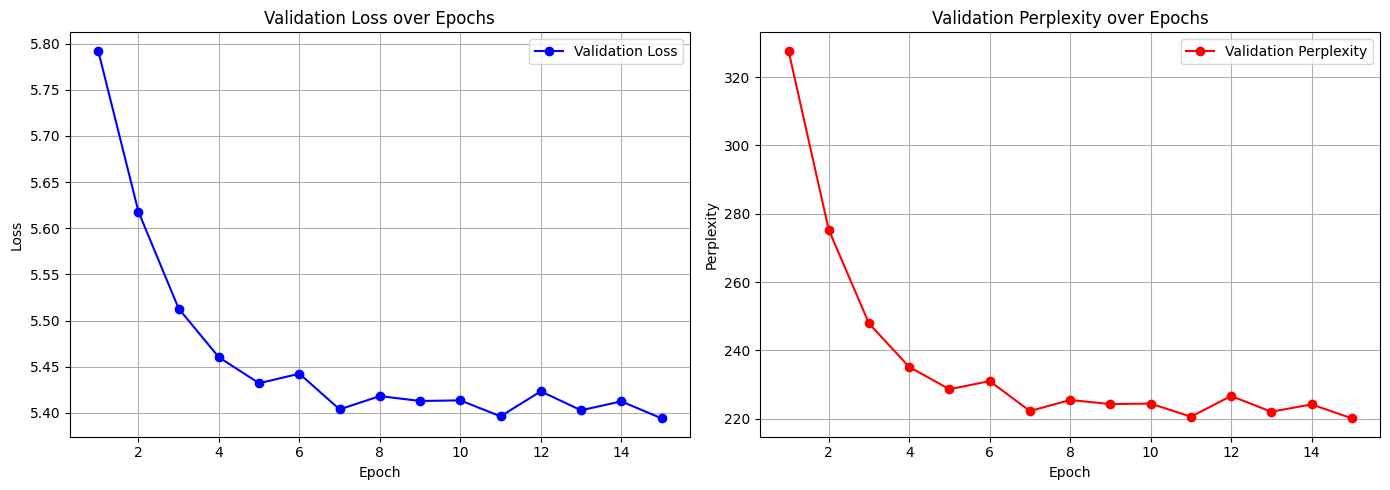


Final Results:
Best Validation Loss: 5.39
Best Validation Perplexity: 220.11


In [128]:
# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot validation loss
ax1.plot(range(1, epochs + 1), val_losses, 'b-o', label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Validation Loss over Epochs')
ax1.grid(True)
ax1.legend()

# Plot validation perplexity
ax2.plot(range(1, epochs + 1), val_ppls, 'r-o', label='Validation Perplexity')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Perplexity')
ax2.set_title('Validation Perplexity over Epochs')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

# Print final results
print(f"\nFinal Results:")
print(f"Best Validation Loss: {best_val_loss:.2f}")
print(f"Best Validation Perplexity: {math.exp(best_val_loss):.2f}")
#print(f"Test Loss: {test_loss:.2f}")
#print(f"Test Perplexity: {test_ppl:.2f}")

### <img src="https://img.icons8.com/color/48/000000/code.png" style="height:50px;display:inline"> Task 5  - Generate Sentences
---
Use the following function to generate 3 sentences of length 20, and print them. Do they make sense? (you can compare generated sentences over epochs, to see if some logic is gained during training).

In [129]:
def generate(model, vocab, nwords=100, temp=1.0):
    model.eval()
    ntokens = len(vocab)
    itos = vocab.vocab.get_itos()
    model_input = torch.randint(ntokens, (1, 1), dtype=torch.long).to(device)
    words = []
    with torch.no_grad():
        for i in range(nwords):
            output = model(model_input, None)
            word_weights = output[-1].squeeze().div(temp).exp().cpu()
            word_idx = torch.multinomial(word_weights, 1)[0]
            word_tensor = torch.Tensor([[word_idx]]).long().to(device)
            model_input = torch.cat([model_input, word_tensor], 0)
            word = itos[word_idx]
            words.append(word)
    return words

In [130]:
# Generate 3 sentences of length 20
print("=== Generated Sentences ===\n")

for i in range(3):
    print(f"Sentence {i+1}:")
    generated_words = generate(best_model, vocab, nwords=20, temp=1.0)
    sentence = " ".join(generated_words)
    print(sentence)
    print()

=== Generated Sentences ===

Sentence 1:
supporting <unk> was first europeans established in the british empire in the russian officers , planned however , to negotiations

Sentence 2:
were one of the most generous characters . in the episodes , the film orlando sentinel had fisa — and

Sentence 3:
flotillas . they resulted in the british japanese shipping defence he has rivaled a new in support of the new



## <img src="https://img.icons8.com/dusk/64/000000/prize.png" style="height:50px;display:inline"> Credits
---
* Icons made by <a href="https://www.flaticon.com/authors/becris" title="Becris">Becris</a> from <a href="https://www.flaticon.com/" title="Flaticon">www.flaticon.com</a>
* Icons from <a href="https://icons8.com/">Icons8.com</a> - https://icons8.com
* Datasets from <a href="https://www.kaggle.com/">Kaggle</a> - https://www.kaggle.com/